# importing and cleaning

# Importing

In [19]:
# Import numerical computing library (used for arrays, math operations)
import numpy as np

# Import pandas for data manipulation (tables, time series, etc.)
import pandas as pd

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import seaborn for better-looking statistical plots
import seaborn as sns

# Import datetime to work with dates
import datetime as dt

# Import warnings module to control warning messages
import warnings

# Import yfinance to download financial market data
import yfinance as yf


# This line hides warning messages (cleaner output, but be careful in real projects)
warnings.filterwarnings('ignore')

# This ensures plots show inside Jupyter Notebook (ignore if not using notebook)
%matplotlib inline




In [20]:
# Get today's date (end date for data)
end = dt.date.today()

# Set start date = 5 years before today
start = end - dt.timedelta(days=365*5)


# Download stock data for Reliance from Yahoo Finance
# auto_adjust=True adjusts prices for splits/dividends
df = yf.download('RELIANCE.NS', start, end, auto_adjust=True)


# yfinance sometimes returns multi-level columns → flatten them
df.columns = df.columns.droplevel(1)


# Convert column names to lowercase for consistency
df.columns = df.columns.str.lower()   # <-- FIXED (removed accidental 'a')


# Drop unnecessary columns (keep only adjusted close price)
df = df.drop(columns=['high', 'low', 'open', 'volume'])


# Ensure index is in datetime format (important for time series analysis)
df.index = pd.to_datetime(df.index)

[*********************100%***********************]  1 of 1 completed


In [21]:
# Create a separate copy of the dataframe
# This ensures that any changes made to df1 DO NOT affect the original df
df1 = df.copy()

# Moving Average Crossover
Long only


Buy and Hold = 1.5032617895624298
Strategy Returns = 1.1671013053217132


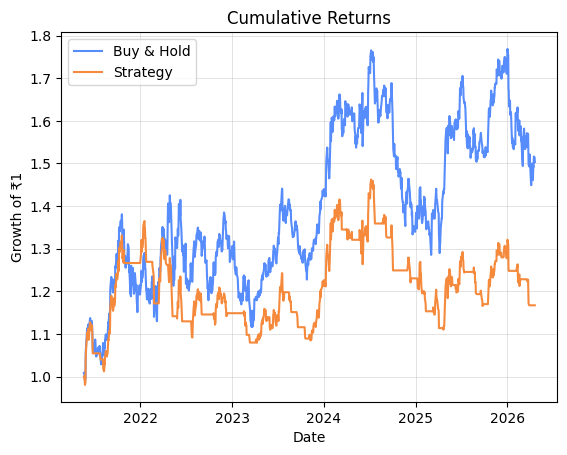

In [22]:
# -------------------------------
# 1. CALCULATE RETURNS
# -------------------------------

# Percentage change in price (daily returns)
# Example: if price goes from 100 → 102, return = 2% (0.02)
df['returns'] = df['close'].pct_change()


# -------------------------------
# 2. CREATE MOVING AVERAGES
# -------------------------------

# Short-term moving average window (fast reaction)
s_ma = 5

# Long-term moving average window (slow trend)
l_ma = 20

# Rolling mean = average of last 'n' values
df['ma_short'] = df['close'].rolling(s_ma).mean()
df['ma_long'] = df['close'].rolling(l_ma).mean()


# -------------------------------
# 3. GENERATE TRADING SIGNAL
# -------------------------------

# If short MA > long MA → uptrend → buy (1)
# Else → no position (0)
df['signal'] = np.where(df['ma_short'] > df['ma_long'], 1, 0)

# Shift signal by 1 day to avoid look-ahead bias
# (you can only act AFTER the signal appears)
df['position'] = df['signal'].shift(1)

# Drop NaN values created by rolling and shifting
df = df.dropna()


# -------------------------------
# 4. STRATEGY RETURNS
# -------------------------------

# Strategy return = market return * position
# If position = 1 → you are in market
# If position = 0 → you are out
df['strategy_return'] = df['returns'] * df['position']

# Convert returns to growth factor
# Example: 2% → 1.02
df['strategy_return'] = 1 + df['strategy_return']

# Buy & Hold growth factor
df['buy_and_hold'] = 1 + df['returns']


# -------------------------------
# 5. PERFORMANCE COMPARISON
# -------------------------------

# Final value of ₹1 invested
print("Buy and Hold =", df['buy_and_hold'].cumprod().iloc[-1])
print("Strategy Returns =", df['strategy_return'].cumprod().iloc[-1])


# -------------------------------
# 6. PLOT RESULTS
# -------------------------------

# Plot cumulative returns over time
plt.plot(df['buy_and_hold'].cumprod(), label='Buy & Hold')
plt.plot(df['strategy_return'].cumprod(), label='Strategy')

plt.title('Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Growth of ₹1')
plt.legend()
plt.grid()

plt.show()

# Rsi Strategy
Long and Short

In [23]:
# Create a working copy so original data remains untouched
dfa = df1.copy()

RSI Strategy Returns =  0.8904217415038788
Buy Hold Returns =  1.540147994734482


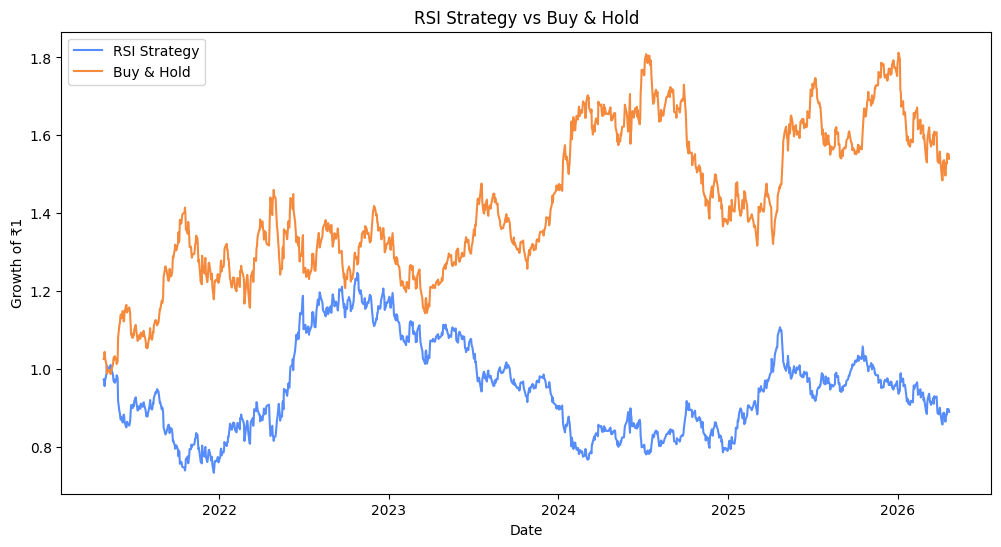

In [24]:



# -------------------------------
# 1. PRICE CHANGE
# -------------------------------

# Difference between today's price and yesterday's price
dfa['change'] = dfa['close'] - dfa['close'].shift(1)


# -------------------------------
# 2. SEPARATE GAINS AND LOSSES
# -------------------------------

# If change > 0 → gain, else 0
dfa['gain'] = dfa['change'].apply(lambda x: x if x > 0 else 0)

# If change < 0 → loss, else 0
dfa['loss'] = dfa['change'].apply(lambda x: x if x < 0 else 0)

# Convert losses to positive values (RSI uses magnitude)
dfa['loss'] = dfa['loss'] * -1


# -------------------------------
# 3. AVERAGE GAIN & LOSS (EMA)
# -------------------------------

# Exponential moving average (more weight to recent data)
dfa['avg_gain'] = dfa['gain'].ewm(span=14, adjust=False).mean()
dfa['avg_loss'] = dfa['loss'].ewm(span=14, adjust=False).mean()

# Remove NaN values created from shifting
dfa.dropna(inplace=True)


# -------------------------------
# 4. CALCULATE RSI
# -------------------------------

# Relative Strength (RS)
dfa['rs'] = dfa['avg_gain'] / dfa['avg_loss']

# RSI formula
dfa['rsi'] = 100 - (100 / (1 + dfa['rs']))


# -------------------------------
# 5. CREATE TRADING SIGNAL
# -------------------------------

# RSI < 30 → oversold → BUY (1)
# RSI > 70 → overbought → SELL (-1)
# Else → no signal (NaN)
dfa['signal'] = np.where(dfa['rsi'] < 30, 1,
                  np.where(dfa['rsi'] > 70, -1, np.nan))


# -------------------------------
# 6. POSITION MANAGEMENT
# -------------------------------

# Forward fill signal → hold position until opposite signal appears
dfa['position'] = dfa['signal'].ffill()

# Replace remaining NaN with 0 (no position)
dfa['position'] = dfa['position'].fillna(0)

# Shift to avoid look-ahead bias
dfa['position'] = dfa['position'].shift(1)


# -------------------------------
# 7. RETURNS
# -------------------------------

# Market returns
dfa['returns'] = dfa['close'].pct_change()

# Strategy returns = returns * position
dfa['strategy_return'] = dfa['returns'] * dfa['position']


# -------------------------------
# 8. PERFORMANCE
# -------------------------------

# Convert to growth factors
dfa['buy_and_hold_returns'] = 1 + dfa['returns']
dfa['strategy_return'] = 1 + dfa['strategy_return']

# Final value of ₹1 invested
print("RSI Strategy Returns = ", dfa['strategy_return'].cumprod().iloc[-1])
print("Buy Hold Returns = ", dfa['buy_and_hold_returns'].cumprod().iloc[-1])


# -------------------------------
# 9. PLOT
# -------------------------------

plt.figure(figsize=(12,6))

plt.plot(dfa['strategy_return'].cumprod(), label='RSI Strategy')
plt.plot(dfa['buy_and_hold_returns'].cumprod(), label='Buy & Hold')

plt.title('RSI Strategy vs Buy & Hold')
plt.ylabel('Growth of ₹1')
plt.xlabel('Date')
plt.legend()

plt.show()

# Breakout Strategy
Long Only


[*********************100%***********************]  1 of 1 completed

Buy and Hold = 18.343939713340593
Breakout Strategy Returns = 3.93771167233896


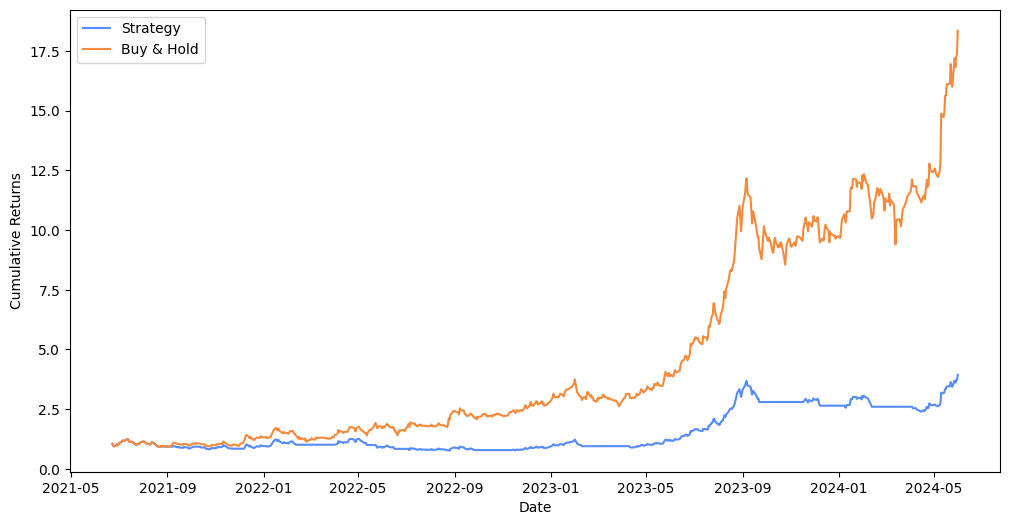

In [25]:
# -------------------------------
# 1. DOWNLOAD DATA
# -------------------------------

# Download stock data for JWL (Jindal Worldwide)
dfb = yf.download('JWL.NS', start='2021-06-01', end='2024-06-01')


# -------------------------------
# 2. CLEAN DATA
# -------------------------------

# Remove multi-level columns (yfinance formatting issue)
dfb.columns = dfb.columns.droplevel(1)

# Convert column names to lowercase
dfb.columns = dfb.columns.str.lower()

# Drop unnecessary columns
dfb.drop(columns=['open', 'volume'], inplace=True)

# Ensure index is datetime
dfb.index = pd.to_datetime(dfb.index)


# -------------------------------
# 3. SUPPORT & RESISTANCE LEVELS
# -------------------------------

# Resistance = highest high of last 15 days (excluding today)
dfb['resistance'] = dfb['high'].rolling(15).max().shift(1)

# Support = lowest low of last 15 days (excluding today)
dfb['support'] = dfb['low'].rolling(15).min().shift(1)

# Remove NaN values created by rolling
dfb.dropna(inplace=True)


# -------------------------------
# 4. GENERATE SIGNAL
# -------------------------------

# If price breaks above resistance → BUY (1)
# If price breaks below support → EXIT (0)
# Else → no new signal (NaN)
dfb['signal'] = np.where(dfb['close'] > dfb['resistance'], 1,
                 np.where(dfb['close'] < dfb['support'], 0, np.nan))

# Forward fill → hold position until exit
dfb['signal'] = dfb['signal'].ffill()

# Replace remaining NaN with 0 (no position)
dfb['signal'] = dfb['signal'].fillna(0)


# -------------------------------
# 5. REMOVE LOOK-AHEAD BIAS
# -------------------------------

# Execute trade next day after signal
dfb['position'] = dfb['signal'].shift(1)


# -------------------------------
# 6. RETURNS
# -------------------------------

# Market returns
dfb['returns'] = dfb['close'].pct_change()

# Strategy returns
dfb['strategy_return'] = dfb['returns'] * dfb['position']


# -------------------------------
# 7. PERFORMANCE
# -------------------------------

# Convert to growth factors
dfb['buy_and_hold_returns'] = 1 + dfb['returns']
dfb['strategy_return'] = 1 + dfb['strategy_return']

# Final value of ₹1 invested
print("Buy and Hold =", dfb['buy_and_hold_returns'].cumprod().iloc[-1])
print("Breakout Strategy Returns =", dfb['strategy_return'].cumprod().iloc[-1])


# -------------------------------
# 8. PLOT RESULTS
# -------------------------------

plt.figure(figsize=(12,6))

plt.plot(dfb['strategy_return'].cumprod(), label='Strategy')
plt.plot(dfb['buy_and_hold_returns'].cumprod(), label='Buy & Hold')

plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()

plt.show()

# Volatility Based Regime Detection

Buy & Hold Returns =  1.4903877998348949
Strategy Returns =  1.0113880879873338


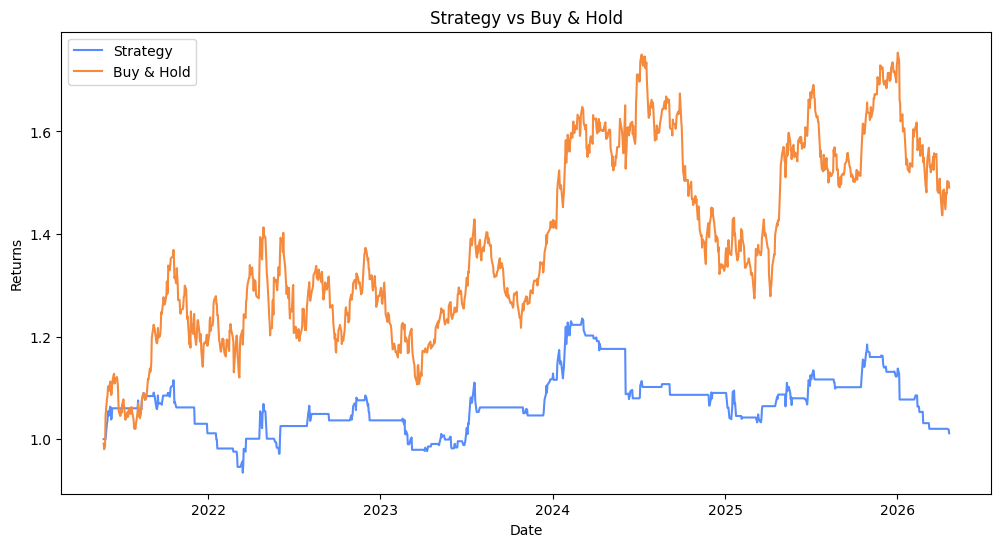

In [26]:
# -------------------------------
# 1. CALCULATE RETURNS
# -------------------------------

# Daily percentage returns
df1['returns'] = df1['close'].pct_change()


# -------------------------------
# 2. VOLATILITY REGIME
# -------------------------------

# Short-term volatility (last 10 days)
df1['short_volatility'] = df1['returns'].rolling(10).std()

# Long-term volatility (last 20 days)
df1['long_volatility'] = df1['returns'].rolling(20).std()

# If short-term vol > long-term vol → high volatility regime (1)
# Else → low volatility (0)
df1['volatility'] = np.where(df1['short_volatility'] > df1['long_volatility'], 1, 0)


# -------------------------------
# 3. TREND FILTER
# -------------------------------

# 21-day moving average
df1['ma'] = df1['close'].rolling(21).mean()

# If price > MA → uptrend (1), else downtrend (0)
df1['trend'] = np.where(df1['close'] > df1['ma'], 1, 0)


# -------------------------------
# 4. TRADING TRIGGER
# -------------------------------

# Only trade when BOTH conditions are true:
# (High volatility AND Uptrend)
df1['trigger'] = df1['volatility'] * df1['trend']

# Shift to avoid look-ahead bias
df1['trigger'] = df1['trigger'].shift(1)

# Remove NaN values from rolling calculations
df1.dropna(inplace=True)


# -------------------------------
# 5. STRATEGY RETURNS
# -------------------------------

# Strategy return = market return * trigger
# If trigger = 1 → in market
# If trigger = 0 → out
df1['strategy_returns'] = df1['returns'] * df1['trigger']


# -------------------------------
# 6. CONVERT TO COMPOUND RETURNS
# -------------------------------

# Convert returns to growth factor
df1['strategy_returns'] = 1 + df1['strategy_returns']
df1['returns'] = 1 + df1['returns']


# -------------------------------
# 7. PERFORMANCE
# -------------------------------

# Final value of ₹1 invested
print("Buy & Hold Returns = ", df1['returns'].cumprod().iloc[-1])
print("Strategy Returns = ", df1['strategy_returns'].cumprod().iloc[-1])


# -------------------------------
# 8. PLOT
# -------------------------------

plt.figure(figsize=(12,6))

plt.plot(df1['strategy_returns'].cumprod(), label='Strategy')
plt.plot(df1['returns'].cumprod(), label='Buy & Hold')

plt.title('Strategy vs Buy & Hold')
plt.ylabel('Returns')
plt.xlabel('Date')
plt.legend()

plt.show()